<a href="https://colab.research.google.com/github/kailashscse2025-alt/DAA/blob/main/DAA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


       DIJKSTRA'S SHORTEST PATH
Vertex    Distance    Path
--------------------------------------------------
0         0           0
1         3           0 -> 2 -> 1
2         1           0 -> 2
3         4           0 -> 2 -> 1 -> 3
4         7           0 -> 2 -> 1 -> 3 -> 4
5         9           0 -> 2 -> 1 -> 3 -> 4 -> 5
--------------------------------------------------


/tmp/ipykernel_2499/3715215235.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2499/3715215235.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


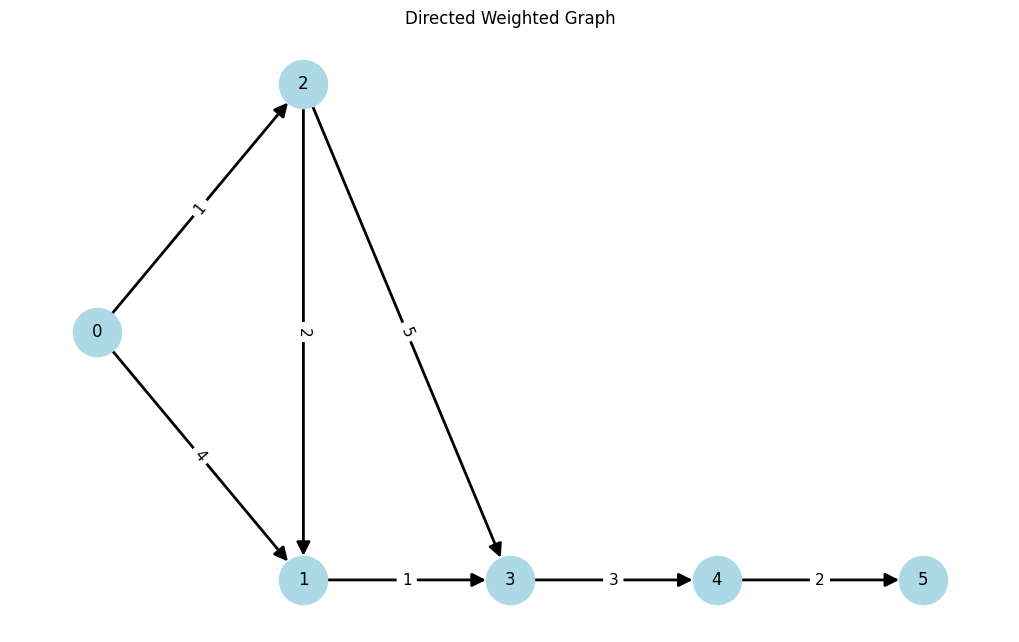

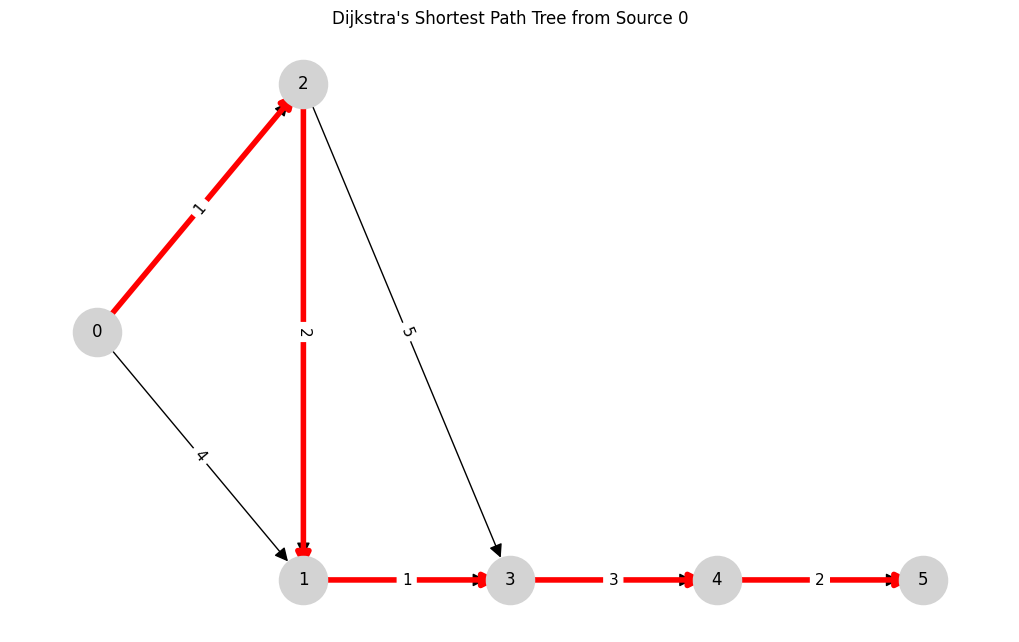

In [1]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx


# ------------------------------------------
# Dijkstra's Algorithm
# ------------------------------------------
def dijkstra(graph, source):
    n = len(graph)

    dist = [float('inf')] * n
    prev = [None] * n

    dist[source] = 0

    pq = [(0, source)]
    visited = set()

    while pq:
        d, u = heapq.heappop(pq)

        if u in visited:
            continue

        visited.add(u)

        for v, w in graph[u]:

            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u

                heapq.heappush(pq, (dist[v], v))

    return dist, prev


# ------------------------------------------
# Reconstruct Path
# ------------------------------------------
def reconstruct_path(prev, source, target):

    path = []
    node = target

    while node is not None:
        path.append(node)
        node = prev[node]

    path.reverse()

    if path[0] == source:
        return path

    return []


# ------------------------------------------
# Graph Definition
# ------------------------------------------
graph = {
    0: [(1, 4), (2, 1)],
    1: [(3, 1)],
    2: [(1, 2), (3, 5)],
    3: [(4, 3)],
    4: [(5, 2)],
    5: []
}

source = 0


# ------------------------------------------
# Run Dijkstra
# ------------------------------------------
dist, prev = dijkstra(graph, source)


# ------------------------------------------
# TABLE OUTPUT
# ------------------------------------------
print("\n==============================================")
print("       DIJKSTRA'S SHORTEST PATH")
print("==============================================")

print(f"{'Vertex':<10}{'Distance':<12}{'Path'}")
print("-" * 50)

for v in range(len(graph)):

    path = reconstruct_path(prev, source, v)

    if path:
        path_str = " -> ".join(map(str, path))
    else:
        path_str = "No path"

    if dist[v] == float('inf'):
        distance = "INF"
    else:
        distance = str(dist[v])

    print(f"{v:<10}{distance:<12}{path_str}")

print("-" * 50)


# ------------------------------------------
# CREATE DIRECTED GRAPH
# ------------------------------------------
G = nx.DiGraph()

for u in graph:

    for v, w in graph[u]:
        G.add_edge(u, v, weight=w)


# Fixed positions for a clean graph
pos = {
    0: (0, 2),
    2: (2, 3),
    1: (2, 1),
    3: (4, 1),
    4: (6, 1),
    5: (8, 1)
}


# ------------------------------------------
# ORIGINAL GRAPH
# ------------------------------------------
plt.figure(figsize=(10, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    node_color="lightblue",
    font_size=12,
    arrows=True,
    arrowsize=20,
    width=2
)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=11
)

plt.title("Directed Weighted Graph")
plt.axis("off")
plt.tight_layout()


# ------------------------------------------
# SHORTEST PATH TREE
# ------------------------------------------

SP = nx.DiGraph()

for v in range(len(graph)):

    if v != source and prev[v] is not None:

        u = prev[v]
        weight = G[u][v]["weight"]

        SP.add_edge(u, v, weight=weight)


# ------------------------------------------
# SHORTEST PATH GRAPH
# ------------------------------------------
plt.figure(figsize=(10, 6))

# Draw original graph
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    node_color="lightgray",
    font_size=12,
    arrows=True,
    arrowsize=20,
    width=1
)

# Highlight shortest path tree
nx.draw_networkx_edges(
    SP,
    pos,
    edge_color="red",
    width=4,
    arrows=True,
    arrowsize=20
)

# Draw edge weights
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=11
)

plt.title("Dijkstra's Shortest Path Tree from Source 0")
plt.axis("off")
plt.tight_layout()

plt.show()